# 06 - Segmentation and Recommendation

Notebook này phân tích hành vi mua sắm ở cấp khách hàng và xây dựng khung recommendation tổng quát, dựa hoàn toàn trên dữ liệu đã làm sạch và các builder hiện có trong project.

**Mục tiêu:**
1. Tạo rule-based segmentation để đọc nhanh chân dung khách hàng.
2. Áp dụng clustering bằng K-Means để phân nhóm tự động theo dữ liệu.
3. Mô tả từng cụm khách hàng theo ngôn ngữ business.
4. Đề xuất cơ chế recommendation gồm cross-sell/up-sell, nhắc chu kỳ mua lặp lại và cá nhân hóa chiến dịch.


## 1. Set Up and Import Existing Project Modules

Notebook này chỉ dùng các tài sản sẵn có của repo:
- `data/cleaned/online_retail_cleaned_full.csv`
- `src.data_contract.run_data_contract_checks`
- `src.features.churn_feature_builder.build_churn_features`
- `src.features.composite_feature_builder.build_composite_features`


In [2]:
import sys
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


def resolve_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'data' / 'cleaned').exists():
            return candidate
        nested = candidate / '404_Not_Found'
        if (nested / 'src').exists() and (nested / 'data' / 'cleaned').exists():
            return nested
    raise FileNotFoundError("Cannot resolve project root containing src/ and data/cleaned/")


PROJECT_ROOT = resolve_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_contract import run_data_contract_checks
from src.features.churn_feature_builder import build_churn_features
from src.features.composite_feature_builder import build_composite_features

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', font_scale=1.0)

print('Project root:', PROJECT_ROOT)
print('Imports loaded successfully.')

Project root: d:\Data impact\404_Not_Found
Imports loaded successfully.


## 2. Load Cleaned Data and Build Customer-Level Features

Ở bước này, notebook sẽ:
- nạp dữ liệu cleaned transaction-level
- chạy data contract check
- chọn `snapshot_date` giống logic churn labeling trong project
- build churn features và composite features
- bổ sung một số behavioral aggregates từ raw transaction để phục vụ segmentation và recommendation


In [3]:
DATA_PATH = PROJECT_ROOT / 'data' / 'cleaned' / 'online_retail_cleaned_full.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['InvoiceDate', 'FirstPurchaseDate'])
contract = run_data_contract_checks(df)

print('Data contract check passed:')
for key, value in contract.items():
    print(f'  {key}: {value}')
print(f'\nData path: {DATA_PATH}')
print(f'Raw shape: {df.shape}')

sales_df = df.loc[df['Quantity'] > 0].copy()
max_date = df['InvoiceDate'].max()
INACTIVITY_DAYS = 60
snapshot_date = max_date - pd.Timedelta(days=INACTIVITY_DAYS)
window_start = snapshot_date - pd.Timedelta(days=89)

churn_features = build_churn_features(
    df,
    snapshot_date=snapshot_date,
    inactivity_days=INACTIVITY_DAYS,
)
composite_features = build_composite_features(churn_features)

sales_history = sales_df.loc[
    (sales_df['InvoiceDate'] >= window_start) & (sales_df['InvoiceDate'] <= snapshot_date)
].copy()

customer_behavior = (
    sales_history.groupby('Customer ID')
    .agg(
        total_units_90d=('Quantity', 'sum'),
        avg_units_per_line_90d=('Quantity', 'mean'),
        distinct_products_90d=('StockCode', 'nunique'),
        distinct_invoices_90d=('Invoice', 'nunique'),
        latest_country=('Country', 'last'),
    )
    .reset_index()
)

invoice_units = (
    sales_history.groupby(['Customer ID', 'Invoice'], as_index=False)
    .agg(invoice_units=('Quantity', 'sum'))
)
invoice_units_summary = (
    invoice_units.groupby('Customer ID', as_index=False)
    .agg(
        avg_units_per_invoice_90d=('invoice_units', 'mean'),
        max_units_per_invoice_90d=('invoice_units', 'max'),
    )
)

customer_df = (
    composite_features
    .merge(customer_behavior, on='Customer ID', how='left')
    .merge(invoice_units_summary, on='Customer ID', how='left')
)

fill_zero_cols = [
    'total_units_90d',
    'avg_units_per_line_90d',
    'distinct_products_90d',
    'distinct_invoices_90d',
    'avg_units_per_invoice_90d',
    'max_units_per_invoice_90d',
]
customer_df[fill_zero_cols] = customer_df[fill_zero_cols].fillna(0)
customer_df['latest_country'] = customer_df['latest_country'].fillna('Unknown')

print(f'Max date:        {max_date}')
print(f'Snapshot date:   {snapshot_date}')
print(f'Window start:    {window_start}')
print(f'Customer table:  {customer_df.shape}')
print(f'Churn rate:      {customer_df["churn_label"].mean():.2%}')

customer_df.head()

Data contract check passed:
  rows: 797885
  columns: 28
  date_min: 2009-12-01 07:45:00
  date_max: 2011-12-09 12:50:00

Data path: d:\Data impact\404_Not_Found\data\cleaned\online_retail_cleaned_full.csv
Raw shape: (797885, 28)


d:\Data impact\404_Not_Found\src\features\churn_feature_builder.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["avg_order_value_90d"] = (features["monetary_90d"] / safe_frequency).fillna(0.0)
d:\Data impact\404_Not_Found\src\features\churn_feature_builder.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["return_rate_90d"] = (features["return_count_90d"] / safe_frequency).fillna(0.0)


Max date:        2011-12-09 12:50:00
Snapshot date:   2011-10-10 12:50:00
Window start:    2011-07-13 12:50:00
Customer table:  (5581, 26)
Churn rate:      62.78%


d:\Data impact\404_Not_Found\src\features\churn_feature_builder.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["recency_velocity"] = (features["recency_days"] / safe_tenure).fillna(0.0)


,Customer ID,snapshot_date,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,return_rate_90d,tenure_days,n_unique_days,avg_days_between_orders,day_of_week_mode,recency_velocity,churn_label,purchase_intensity,loyalty_score,retention_score,customer_value_score,churn_risk_index,rfm_segment,total_units_90d,avg_units_per_line_90d,distinct_products_90d,distinct_invoices_90d,latest_country,avg_units_per_invoice_90d,max_units_per_invoice_90d
0,12346,2011-10-10 12:50:00,265,0,0.000,0.000,0.000,665,11,8.543,0,0.398,1,0.000,0.477,0.602,0.158,0.748,Hibernating,0.000,0.000,0.000,0.000,Unknown,0.000,0.000
1,12347,2011-10-10 12:50:00,69,22,584.910,26.587,0.000,343,6,1.669,1,0.201,0,0.064,0.425,0.799,0.165,0.626,Loyal,277.000,12.591,22.000,1.000,Iceland,277.000,277.000
2,12348,2011-10-10 12:50:00,14,3,310.000,103.333,0.000,377,5,7.240,0,0.037,1,0.008,0.461,0.963,0.163,0.598,Loyal,217.000,72.333,3.000,1.000,Finland,217.000,217.000
3,12349,2011-10-10 12:50:00,347,0,0.000,0.000,0.000,675,4,3.075,3,0.514,0,0.000,0.445,0.486,0.158,0.796,Lost,0.000,0.000,0.000,0.000,Unknown,0.000,0.000
4,12350,2011-10-10 12:50:00,249,0,0.000,0.000,0.000,249,1,0.000,2,1.000,1,0.000,0.300,0.000,0.158,0.738,Hibernating,0.000,0.000,0.000,0.000,Unknown,0.000,0.000


## 3. Customer Model Split and Rule-Based Segmentation

Phần này được tách thành 2 lớp rõ ràng hơn:
- phân loại khách trước thành `B2C / Consumer-like` hoặc `B2B / Account-like`
- với mỗi nhóm, áp dụng rule-based segmentation riêng thay vì dùng chung một bộ nhãn
- nhánh B2C ưu tiên loyalty, recency, cross-sell và reactivation
- nhánh B2B ưu tiên account value, quy mô đơn hàng, volume buying và account risk

In [4]:
value_q80 = customer_df['customer_value_score'].quantile(0.80)
value_q85 = customer_df['customer_value_score'].quantile(0.85)
loyalty_q75 = customer_df['loyalty_score'].quantile(0.75)
churn_q75 = customer_df['churn_risk_index'].quantile(0.75)
recency_q80 = customer_df['recency_days'].quantile(0.80)
frequency_q75 = customer_df['frequency_90d'].quantile(0.75)
aov_q85 = customer_df['avg_order_value_90d'].quantile(0.85)
monetary_q90 = customer_df['monetary_90d'].quantile(0.90)
units_invoice_q85 = customer_df['avg_units_per_invoice_90d'].quantile(0.85)
units_invoice_q90 = customer_df['avg_units_per_invoice_90d'].quantile(0.90)
units_total_q90 = customer_df['total_units_90d'].quantile(0.90)
products_q75 = customer_df['distinct_products_90d'].quantile(0.75)
invoices_q80 = customer_df['distinct_invoices_90d'].quantile(0.80)


def assign_customer_model(row: pd.Series) -> str:
    b2b_signals = 0
    if row['avg_units_per_invoice_90d'] >= units_invoice_q90:
        b2b_signals += 1
    if row['total_units_90d'] >= units_total_q90:
        b2b_signals += 1
    if row['avg_order_value_90d'] >= aov_q85:
        b2b_signals += 1
    if row['monetary_90d'] >= monetary_q90 and row['distinct_invoices_90d'] >= invoices_q80:
        b2b_signals += 1
    return 'B2B / Account-like' if b2b_signals >= 2 else 'B2C / Consumer-like'


def assign_b2c_segment(row: pd.Series) -> str:
    if (
        row['customer_value_score'] >= value_q80
        and row['loyalty_score'] >= loyalty_q75
        and row['recency_days'] <= 30
    ):
        return 'VIP / Loyal'
    if row['frequency_90d'] <= 1 and row['n_unique_days'] <= 1:
        return 'One-time / Occasional'
    if row['churn_risk_index'] >= churn_q75 or row['rfm_segment'] in {'At Risk', "Can't Lose Them", 'Lost', 'Hibernating'}:
        return 'At Risk / Churned'
    if row['distinct_products_90d'] >= products_q75 and row['frequency_90d'] >= 2:
        return 'Explorer / Cross-sell Ready'
    return 'Core Active'


def assign_b2b_segment(row: pd.Series) -> str:
    if (
        row['customer_value_score'] >= value_q85
        and row['monetary_90d'] >= monetary_q90
        and row['distinct_invoices_90d'] >= invoices_q80
    ):
        return 'Key Account / Strategic'
    if row['avg_units_per_invoice_90d'] >= units_invoice_q85 or row['total_units_90d'] >= units_total_q90:
        return 'Bulk / Wholesale'
    if row['churn_risk_index'] >= churn_q75 or row['recency_days'] >= recency_q80:
        return 'At Risk Account'
    if row['frequency_90d'] >= frequency_q75 and row['distinct_products_90d'] >= products_q75:
        return 'Growth Account'
    return 'Transactional Account'


customer_df['customer_model'] = customer_df.apply(assign_customer_model, axis=1)
customer_df['behavior_segment'] = customer_df.apply(
    lambda row: assign_b2b_segment(row) if row['customer_model'] == 'B2B / Account-like' else assign_b2c_segment(row),
    axis=1,
)

customer_model_summary = (
    customer_df.groupby('customer_model')
    .agg(
        customers=('Customer ID', 'nunique'),
        median_monetary_90d=('monetary_90d', 'median'),
        median_frequency_90d=('frequency_90d', 'median'),
        median_recency_days=('recency_days', 'median'),
        median_avg_units_per_invoice_90d=('avg_units_per_invoice_90d', 'median'),
        churn_rate=('churn_label', 'mean'),
    )
)
customer_model_summary['share_pct'] = (
    customer_model_summary['customers'] / customer_model_summary['customers'].sum() * 100
).round(2)

segment_summary = (
    customer_df.groupby(['customer_model', 'behavior_segment'])
    .agg(
        customers=('Customer ID', 'nunique'),
        recency_days=('recency_days', 'median'),
        frequency_90d=('frequency_90d', 'median'),
        monetary_90d=('monetary_90d', 'median'),
        avg_units_per_invoice_90d=('avg_units_per_invoice_90d', 'median'),
        distinct_products_90d=('distinct_products_90d', 'median'),
        churn_risk_index=('churn_risk_index', 'median'),
        churn_rate=('churn_label', 'mean'),
    )
    .sort_values(['customer_model', 'customers', 'monetary_90d'], ascending=[True, False, False])
)
segment_summary['share_within_model_pct'] = (
    segment_summary['customers']
    / segment_summary.groupby(level=0)['customers'].transform('sum')
    * 100
).round(2)

print('Customer model split:')
display(customer_model_summary.reset_index())
print('\nModel-specific rule-based segment distribution:')
display(segment_summary.reset_index())

Customer model split:


,customer_model,customers,median_monetary_90d,median_frequency_90d,median_recency_days,median_avg_units_per_invoice_90d,churn_rate,share_pct
0,B2B / Account-like,658,"1,271.070",54.000,14.000,386.000,0.267,11.790
1,B2C / Consumer-like,4923,0.000,0.000,193.000,0.000,0.676,88.210



Model-specific rule-based segment distribution:


,customer_model,behavior_segment,customers,recency_days,frequency_90d,monetary_90d,avg_units_per_invoice_90d,distinct_products_90d,churn_risk_index,churn_rate,share_within_model_pct
0,B2B / Account-like,Key Account / Strategic,504,12.000,69.000,"1,549.855",362.167,56.000,0.583,0.212,76.600
1,B2B / Account-like,Bulk / Wholesale,151,25.000,24.000,605.800,428.000,23.000,0.600,0.457,22.950
2,B2B / Account-like,Transactional Account,3,23.000,16.000,976.810,103.500,15.000,0.598,0.000,0.460
3,B2C / Consumer-like,Core Active,1568,97.000,0.000,0.000,0.000,0.000,0.648,0.591,31.850
4,B2C / Consumer-like,One-time / Occasional,1302,375.000,0.000,0.000,0.000,0.000,0.812,0.881,26.450
5,B2C / Consumer-like,At Risk / Churned,1161,347.000,0.000,0.000,0.000,0.000,0.796,0.803,23.580
6,B2C / Consumer-like,Explorer / Cross-sell Ready,722,27.000,30.000,392.445,186.000,29.000,0.599,0.377,14.670
7,B2C / Consumer-like,VIP / Loyal,170,12.000,48.000,634.625,184.833,43.000,0.588,0.300,3.450


## 4. Data-Driven Segmentation Within Each Customer Model

Sau khi đã tách `B2B / Account-like` và `B2C / Consumer-like`, clustering sẽ được chạy riêng trong từng nhóm để tránh hai hành vi rất khác nhau kéo méo cùng một không gian đặc trưng. Ở đây:
- chuẩn hóa feature trong từng customer model
- thử nhiều giá trị `k` phù hợp với quy mô từng nhóm
- chọn `k` theo silhouette score tốt nhất trong từng nhánh

In [5]:
cluster_cols = [
    'recency_days',
    'frequency_90d',
    'monetary_90d',
    'avg_order_value_90d',
    'return_rate_90d',
    'tenure_days',
    'customer_value_score',
    'loyalty_score',
    'churn_risk_index',
    'avg_units_per_invoice_90d',
    'total_units_90d',
    'distinct_products_90d',
]

log_cols = [
    'frequency_90d',
    'monetary_90d',
    'avg_order_value_90d',
    'tenure_days',
    'avg_units_per_invoice_90d',
    'total_units_90d',
    'distinct_products_90d',
]

cluster_score_frames = []
cluster_assignment_frames = []
cluster_profile_frames = []

for customer_model, model_customers in customer_df.groupby('customer_model'):
    model_code = 'B2B' if customer_model.startswith('B2B') else 'B2C'
    cluster_model_df = model_customers[['Customer ID'] + cluster_cols].copy().fillna(0.0)

    for col in log_cols:
        cluster_model_df[col] = np.log1p(cluster_model_df[col].clip(lower=0.0))

    max_candidate_k = min(6, len(cluster_model_df) - 1)
    candidate_ks = list(range(2, max_candidate_k + 1))

    if not candidate_ks:
        single_cluster_id = f'{model_code}-0'
        cluster_assignment_frames.append(
            model_customers[['Customer ID']].assign(cluster_id=single_cluster_id)
        )
        cluster_score_frames.append(
            pd.DataFrame([
                {
                    'customer_model': customer_model,
                    'k': 1,
                    'silhouette_score': np.nan,
                    'selected': True,
                }
            ])
        )
        profile = (
            model_customers.assign(cluster_id=single_cluster_id)
            .groupby('cluster_id')
            .agg(
                customers=('Customer ID', 'nunique'),
                recency_days=('recency_days', 'median'),
                frequency_90d=('frequency_90d', 'median'),
                monetary_90d=('monetary_90d', 'median'),
                avg_order_value_90d=('avg_order_value_90d', 'median'),
                total_units_90d=('total_units_90d', 'median'),
                avg_units_per_invoice_90d=('avg_units_per_invoice_90d', 'median'),
                distinct_products_90d=('distinct_products_90d', 'median'),
                loyalty_score=('loyalty_score', 'median'),
                customer_value_score=('customer_value_score', 'median'),
                churn_risk_index=('churn_risk_index', 'median'),
                churn_rate=('churn_label', 'mean'),
            )
            .reset_index()
        )
        profile['customer_model'] = customer_model
        cluster_profile_frames.append(profile)
        continue

    X_scaled = StandardScaler().fit_transform(cluster_model_df[cluster_cols])
    candidate_scores = []

    for k in candidate_ks:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        if len(np.unique(labels)) < 2:
            continue
        score = silhouette_score(X_scaled, labels)
        candidate_scores.append({'customer_model': customer_model, 'k': k, 'silhouette_score': score})

    model_scores = pd.DataFrame(candidate_scores).sort_values('silhouette_score', ascending=False)
    best_k = int(model_scores.iloc[0]['k']) if not model_scores.empty else candidate_ks[0]
    model_scores['selected'] = model_scores['k'].eq(best_k)
    cluster_score_frames.append(model_scores)

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    cluster_ids = [f'{model_code}-{int(label)}' for label in labels]

    cluster_assignment_frames.append(
        model_customers[['Customer ID']].assign(cluster_id=cluster_ids)
    )

    model_with_cluster = model_customers.copy()
    model_with_cluster['cluster_id'] = cluster_ids
    profile = (
        model_with_cluster.groupby('cluster_id')
        .agg(
            customers=('Customer ID', 'nunique'),
            recency_days=('recency_days', 'median'),
            frequency_90d=('frequency_90d', 'median'),
            monetary_90d=('monetary_90d', 'median'),
            avg_order_value_90d=('avg_order_value_90d', 'median'),
            total_units_90d=('total_units_90d', 'median'),
            avg_units_per_invoice_90d=('avg_units_per_invoice_90d', 'median'),
            distinct_products_90d=('distinct_products_90d', 'median'),
            loyalty_score=('loyalty_score', 'median'),
            customer_value_score=('customer_value_score', 'median'),
            churn_risk_index=('churn_risk_index', 'median'),
            churn_rate=('churn_label', 'mean'),
        )
        .reset_index()
    )
    profile['customer_model'] = customer_model
    cluster_profile_frames.append(profile)

cluster_scores = pd.concat(cluster_score_frames, ignore_index=True)
cluster_assignments = pd.concat(cluster_assignment_frames, ignore_index=True)
customer_df = customer_df.drop(columns=['cluster_id'], errors='ignore').merge(
    cluster_assignments,
    on='Customer ID',
    how='left',
)

cluster_profile = pd.concat(cluster_profile_frames, ignore_index=True)
cluster_profile['share_pct'] = (
    cluster_profile['customers']
    / cluster_profile.groupby('customer_model')['customers'].transform('sum')
    * 100
).round(2)
cluster_profile = cluster_profile.sort_values(['customer_model', 'customer_value_score'], ascending=[True, False])

print('Candidate k by silhouette score inside each customer model:')
display(cluster_scores)
print('\nCluster profile:')
display(cluster_profile)

Candidate k by silhouette score inside each customer model:


,customer_model,k,silhouette_score,selected
0,B2B / Account-like,4,0.237,True
1,B2B / Account-like,3,0.225,False
2,B2B / Account-like,5,0.225,False
3,B2B / Account-like,6,0.208,False
4,B2B / Account-like,2,0.179,False
5,B2C / Consumer-like,3,0.649,True
6,B2C / Consumer-like,2,0.635,False
7,B2C / Consumer-like,4,0.621,False
8,B2C / Consumer-like,6,0.450,False
9,B2C / Consumer-like,5,0.436,False



Cluster profile:


,cluster_id,customers,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,total_units_90d,avg_units_per_invoice_90d,distinct_products_90d,loyalty_score,customer_value_score,churn_risk_index,churn_rate,customer_model,share_pct
3,B2B-3,19,3.000,325.000,"23,058.410",111.496,"15,228.000","1,043.833",220.000,0.636,0.330,0.465,0.000,B2B / Account-like,2.890
0,B2B-0,347,12.000,74.000,"1,485.750",20.441,936.000,344.000,61.000,0.583,0.178,0.581,0.170,B2B / Account-like,52.740
1,B2B-1,117,15.000,54.000,"1,206.360",18.442,744.000,394.000,51.000,0.336,0.173,0.586,0.368,B2B / Account-like,17.780
2,B2B-2,175,28.000,17.000,906.720,59.250,616.000,458.000,15.000,0.536,0.168,0.602,0.423,B2B / Account-like,26.600
4,B2C-0,1545,26.000,22.000,326.120,16.397,188.000,147.000,20.000,0.482,0.163,0.600,0.436,B2C / Consumer-like,31.380
5,B2C-1,3337,322.000,0.000,0.000,0.000,0.000,0.000,0.000,0.326,0.158,0.781,0.788,B2C / Consumer-like,67.780
6,B2C-2,41,61.000,2.000,-18.500,-8.630,0.000,0.000,0.000,0.528,0.158,0.627,0.610,B2C / Consumer-like,0.830


## 5. Describe B2B and B2C Cluster Personas

K-Means vẫn chỉ tạo ra các cụm kỹ thuật. Ở bước này, mỗi cụm sẽ được gán persona riêng theo từng nhánh `B2B` hoặc `B2C`, để phần diễn giải business và recommendation không còn dùng cùng một bộ nhãn cho hai loại khách hàng rất khác nhau.

In [6]:
cluster_profile = cluster_profile.copy()
persona_frames = []

for customer_model, model_profile in cluster_profile.groupby('customer_model'):
    working_profile = model_profile.copy()
    profile_indexed = working_profile.set_index('cluster_id')
    remaining_clusters = list(profile_indexed.index)
    persona_map = {}

    if customer_model.startswith('B2B'):
        strategic_cluster = (
            profile_indexed['customer_value_score']
            + profile_indexed['avg_order_value_90d'].rank(pct=True)
            - 0.25 * profile_indexed['churn_risk_index']
        ).idxmax()
        persona_map[strategic_cluster] = 'Strategic Account'
        remaining_clusters.remove(strategic_cluster)

        if remaining_clusters:
            volume_cluster = profile_indexed.loc[remaining_clusters, 'avg_units_per_invoice_90d'].idxmax()
            persona_map[volume_cluster] = 'Volume Buyer'
            remaining_clusters.remove(volume_cluster)

        if remaining_clusters:
            risk_cluster = (
                profile_indexed.loc[remaining_clusters, 'churn_risk_index']
                + profile_indexed.loc[remaining_clusters, 'churn_rate']
            ).idxmax()
            persona_map[risk_cluster] = 'At Risk Account'
            remaining_clusters.remove(risk_cluster)

        if remaining_clusters:
            growth_cluster = (
                profile_indexed.loc[remaining_clusters, 'frequency_90d']
                + profile_indexed.loc[remaining_clusters, 'distinct_products_90d']
            ).idxmax()
            persona_map[growth_cluster] = 'Growth Account'
            remaining_clusters.remove(growth_cluster)

        for cluster_id in remaining_clusters:
            persona_map[cluster_id] = 'Core Account'
    else:
        vip_cluster = (
            profile_indexed['customer_value_score']
            + profile_indexed['loyalty_score']
            - 0.25 * profile_indexed['churn_risk_index']
        ).idxmax()
        persona_map[vip_cluster] = 'VIP / High Value'
        remaining_clusters.remove(vip_cluster)

        if remaining_clusters:
            risk_cluster = (
                profile_indexed.loc[remaining_clusters, 'churn_risk_index']
                + profile_indexed.loc[remaining_clusters, 'churn_rate']
            ).idxmax()
            persona_map[risk_cluster] = 'At Risk / Churned'
            remaining_clusters.remove(risk_cluster)

        if remaining_clusters:
            occasional_cluster = (
                profile_indexed.loc[remaining_clusters, 'recency_days']
                - 0.2 * profile_indexed.loc[remaining_clusters, 'frequency_90d']
                - 0.001 * profile_indexed.loc[remaining_clusters, 'monetary_90d']
            ).idxmax()
            persona_map[occasional_cluster] = 'Occasional / One-time'
            remaining_clusters.remove(occasional_cluster)

        if remaining_clusters:
            explorer_cluster = (
                profile_indexed.loc[remaining_clusters, 'distinct_products_90d']
                + 0.2 * profile_indexed.loc[remaining_clusters, 'frequency_90d']
            ).idxmax()
            persona_map[explorer_cluster] = 'Explorer / Basket Builder'
            remaining_clusters.remove(explorer_cluster)

        for cluster_id in remaining_clusters:
            persona_map[cluster_id] = 'Core Consumer'

    working_profile['persona'] = working_profile['cluster_id'].map(persona_map)
    persona_frames.append(working_profile)

cluster_profile = pd.concat(persona_frames, ignore_index=True)
customer_df = customer_df.drop(columns=['persona'], errors='ignore').merge(
    cluster_profile[['cluster_id', 'persona']],
    on='cluster_id',
    how='left',
)

persona_mix = (
    customer_df.groupby(['customer_model', 'cluster_id', 'persona', 'behavior_segment'])
    .size()
    .reset_index(name='customers')
    .sort_values(['customer_model', 'cluster_id', 'customers'], ascending=[True, True, False])
)

print('Cluster persona mapping:')
display(cluster_profile)
print('\nTop rule-based segment inside each cluster:')
display(persona_mix.groupby(['customer_model', 'cluster_id', 'persona']).head(3))

Cluster persona mapping:


,cluster_id,customers,recency_days,frequency_90d,monetary_90d,avg_order_value_90d,total_units_90d,avg_units_per_invoice_90d,distinct_products_90d,loyalty_score,customer_value_score,churn_risk_index,churn_rate,customer_model,share_pct,persona
0,B2B-3,19,3.000,325.000,"23,058.410",111.496,"15,228.000","1,043.833",220.000,0.636,0.330,0.465,0.000,B2B / Account-like,2.890,Strategic Account
1,B2B-0,347,12.000,74.000,"1,485.750",20.441,936.000,344.000,61.000,0.583,0.178,0.581,0.170,B2B / Account-like,52.740,Growth Account
2,B2B-1,117,15.000,54.000,"1,206.360",18.442,744.000,394.000,51.000,0.336,0.173,0.586,0.368,B2B / Account-like,17.780,At Risk Account
3,B2B-2,175,28.000,17.000,906.720,59.250,616.000,458.000,15.000,0.536,0.168,0.602,0.423,B2B / Account-like,26.600,Volume Buyer
4,B2C-0,1545,26.000,22.000,326.120,16.397,188.000,147.000,20.000,0.482,0.163,0.600,0.436,B2C / Consumer-like,31.380,Occasional / One-time
5,B2C-1,3337,322.000,0.000,0.000,0.000,0.000,0.000,0.000,0.326,0.158,0.781,0.788,B2C / Consumer-like,67.780,At Risk / Churned
6,B2C-2,41,61.000,2.000,-18.500,-8.630,0.000,0.000,0.000,0.528,0.158,0.627,0.610,B2C / Consumer-like,0.830,VIP / High Value



Top rule-based segment inside each cluster:


,customer_model,cluster_id,persona,behavior_segment,customers
1,B2B / Account-like,B2B-0,Growth Account,Key Account / Strategic,315
0,B2B / Account-like,B2B-0,Growth Account,Bulk / Wholesale,32
3,B2B / Account-like,B2B-1,At Risk Account,Key Account / Strategic,84
2,B2B / Account-like,B2B-1,At Risk Account,Bulk / Wholesale,33
4,B2B / Account-like,B2B-2,Volume Buyer,Bulk / Wholesale,86
5,B2B / Account-like,B2B-2,Volume Buyer,Key Account / Strategic,86
6,B2B / Account-like,B2B-2,Volume Buyer,Transactional Account,3
7,B2B / Account-like,B2B-3,Strategic Account,Key Account / Strategic,19
9,B2C / Consumer-like,B2C-0,Occasional / One-time,Explorer / Cross-sell Ready,722
8,B2C / Consumer-like,B2C-0,Occasional / One-time,Core Active,646


## 6. Visualize Segment and Cluster Profiles

Biểu đồ ở phần này giúp kiểm tra nhanh cả hai nhánh:
- tỷ trọng segment trong từng `customer_model`
- cụm nào có giá trị cao nhưng đang tăng rủi ro
- B2B và B2C có đang tạo ra các persona khác nhau đủ rõ hay không

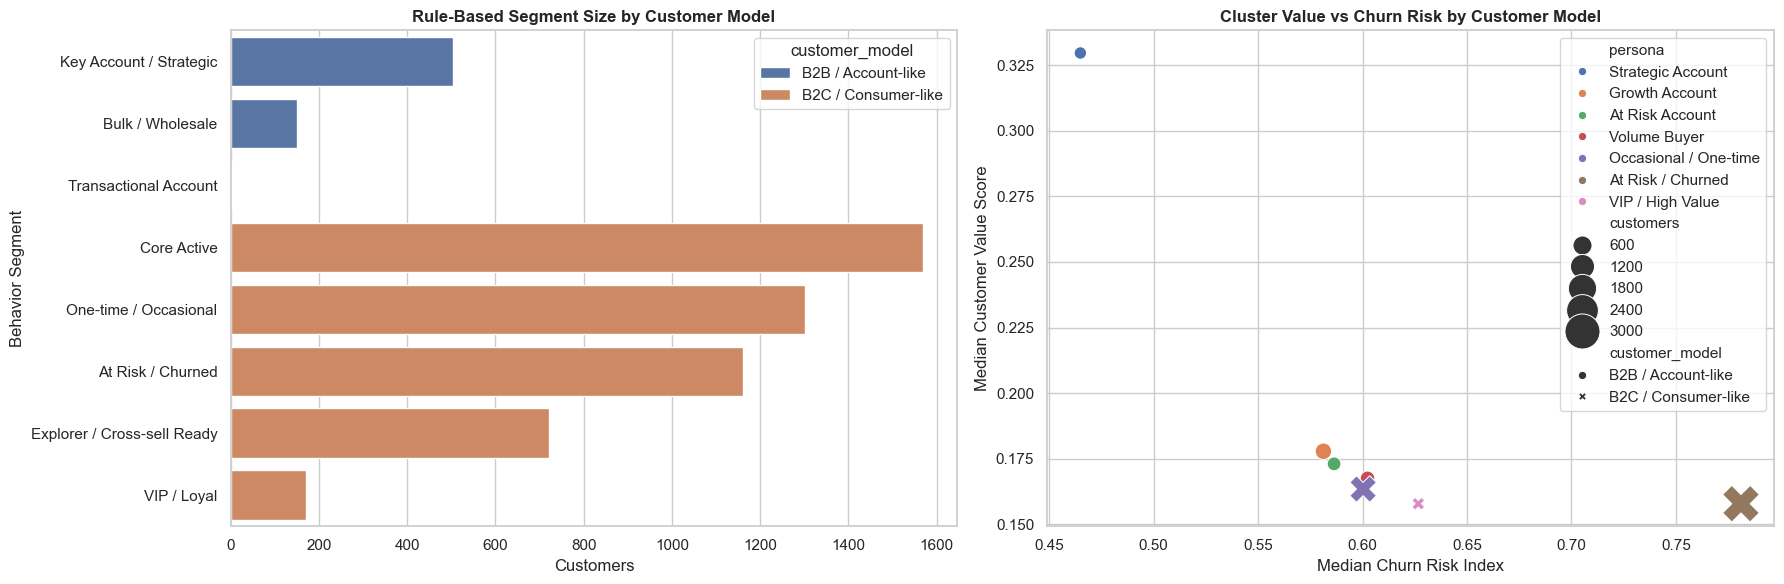

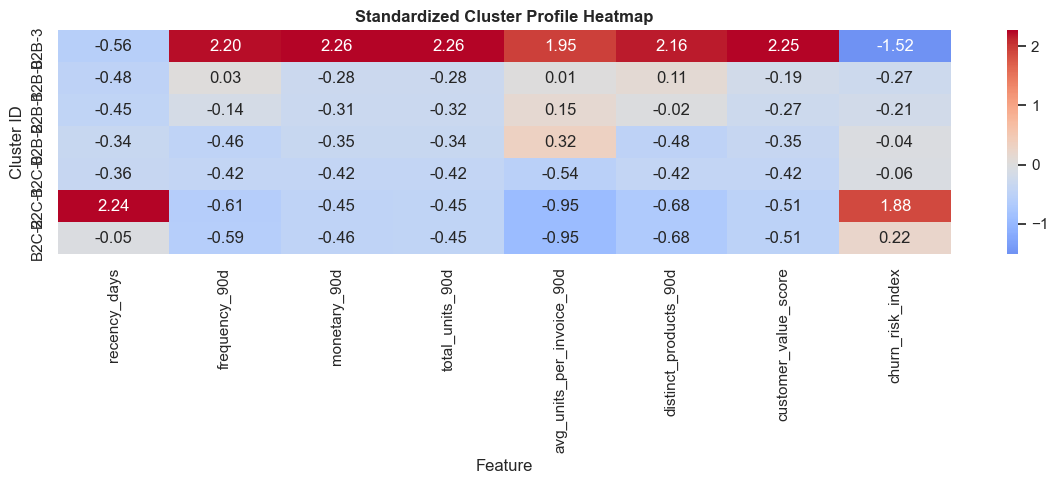

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

segment_plot = segment_summary.reset_index().sort_values(
    ['customer_model', 'customers'],
    ascending=[True, False],
)
sns.barplot(
    data=segment_plot,
    x='customers',
    y='behavior_segment',
    hue='customer_model',
    ax=axes[0],
)
axes[0].set_title('Rule-Based Segment Size by Customer Model', fontweight='bold')
axes[0].set_xlabel('Customers')
axes[0].set_ylabel('Behavior Segment')

cluster_plot = cluster_profile.sort_values(['customer_model', 'customer_value_score'], ascending=[True, False])
sns.scatterplot(
    data=cluster_plot,
    x='churn_risk_index',
    y='customer_value_score',
    size='customers',
    hue='persona',
    style='customer_model',
    ax=axes[1],
    sizes=(80, 700),
)
axes[1].set_title('Cluster Value vs Churn Risk by Customer Model', fontweight='bold')
axes[1].set_xlabel('Median Churn Risk Index')
axes[1].set_ylabel('Median Customer Value Score')

plt.tight_layout()
plt.show()

cluster_heatmap = cluster_profile.set_index('cluster_id')[
    [
        'recency_days',
        'frequency_90d',
        'monetary_90d',
        'total_units_90d',
        'avg_units_per_invoice_90d',
        'distinct_products_90d',
        'customer_value_score',
        'churn_risk_index',
    ]
].copy()
cluster_heatmap = cluster_heatmap.apply(
    lambda col: (col - col.mean()) / (col.std() if col.std() else 1),
    axis=0,
)

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_heatmap, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Standardized Cluster Profile Heatmap', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

## 7. Recommendation Logic

Recommendation ở phần này được tách chặt hơn theo business context:
- **B2B / Account-like**: giữ product-level cross-sell nhưng tách theo `country` để tránh trộn assortment giữa các thị trường
- **B2C / Consumer-like**: bỏ pair-level affinity ở cấp SKU, chuyển sang `category-level affinity` và `next-best-category`
- mỗi recommendation sẽ giữ lại `cross_sell_source` và `cross_sell_level` để phân biệt rõ mức bằng chứng đang dùng

In [20]:
recent_sales = sales_df.loc[sales_df['InvoiceDate'] >= max_date - pd.Timedelta(days=180)].copy()
recent_sales['product_label'] = recent_sales['Description'].fillna('Unknown Product').str.strip()
recent_sales['product_label'] = recent_sales['product_label'].replace('', 'Unknown Product')
recent_sales['product_category'] = recent_sales['ProductCategory'].fillna('Unknown Category').str.strip()
recent_sales['product_category'] = recent_sales['product_category'].replace('', 'Unknown Category')

# Make the cell safe to rerun by clearing previously derived recommendation columns.
recommendation_cols = [
    'last_product',
    'last_category',
    'last_purchase_date',
    'median_reorder_cycle_days',
    'reorder_due',
    'recommendation_type',
    'campaign_action',
    'cross_sell_candidates',
    'cross_sell_source',
    'cross_sell_level',
    'next_best_category',
    'market_scope',
    'b2b_country_group',
]
customer_df = customer_df.drop(columns=recommendation_cols, errors='ignore')

b2b_country_counts = (
    customer_df.loc[customer_df['customer_model'] == 'B2B / Account-like', 'latest_country']
    .fillna('Unknown')
    .replace('', 'Unknown')
    .value_counts()
)
major_b2b_countries = set(
    b2b_country_counts[(b2b_country_counts >= 15) & (b2b_country_counts.index != 'Unknown')].index
)
if 'United Kingdom' in b2b_country_counts.index:
    major_b2b_countries.add('United Kingdom')


def assign_b2b_country_group(country: str) -> str:
    if pd.isna(country) or not str(country).strip():
        return 'Unknown'
    country = str(country).strip()
    if country == 'Unknown':
        return 'Unknown'
    if country in major_b2b_countries:
        return country
    return 'Other International'


customer_df['b2b_country_group'] = np.where(
    customer_df['customer_model'] == 'B2B / Account-like',
    customer_df['latest_country'].map(assign_b2b_country_group),
    'B2C / Consumer-like',
)
customer_df['market_scope'] = np.where(
    customer_df['customer_model'] == 'B2B / Account-like',
    customer_df['b2b_country_group'],
    'B2C / Consumer-like',
)

recent_sales = recent_sales.merge(
    customer_df[['Customer ID', 'customer_model', 'behavior_segment', 'b2b_country_group']],
    on='Customer ID',
    how='inner',
)

b2b_recent_sales = recent_sales.loc[recent_sales['customer_model'] == 'B2B / Account-like'].copy()
b2c_recent_sales = recent_sales.loc[recent_sales['customer_model'] == 'B2C / Consumer-like'].copy()

# B2B: mine product affinity separately by country bucket to keep market assortments distinct.
b2b_top_products = (
    b2b_recent_sales.groupby(['b2b_country_group', 'product_label'])['Invoice']
    .nunique()
    .reset_index(name='invoice_count')
    .sort_values(['b2b_country_group', 'invoice_count'], ascending=[True, False])
)
b2b_top_products = b2b_top_products.groupby('b2b_country_group').head(120)
b2b_recent_sales = b2b_recent_sales.merge(
    b2b_top_products[['b2b_country_group', 'product_label']],
    on=['b2b_country_group', 'product_label'],
    how='inner',
)

b2b_invoice_products = (
    b2b_recent_sales.groupby(['b2b_country_group', 'Invoice'])['product_label']
    .apply(lambda s: sorted(set(s)))
    .reset_index(name='products')
)
b2b_invoice_products = b2b_invoice_products[
    b2b_invoice_products['products'].apply(lambda items: 2 <= len(items) <= 12)
]

b2b_pair_counter = Counter()
for row in b2b_invoice_products.itertuples(index=False):
    for product_a, product_b in combinations(row.products, 2):
        b2b_pair_counter[(row.b2b_country_group, product_a, product_b)] += 1

b2b_pair_rows = [
    {
        'b2b_country_group': country_group,
        'product_a': product_a,
        'product_b': product_b,
        'pair_count': count,
    }
    for (country_group, product_a, product_b), count in b2b_pair_counter.items()
]
b2b_product_pairs = pd.DataFrame(b2b_pair_rows)
if b2b_product_pairs.empty:
    b2b_product_pairs = pd.DataFrame(
        columns=['b2b_country_group', 'product_a', 'product_b', 'pair_count', 'support_pct']
    )
else:
    b2b_invoice_base = (
        b2b_invoice_products.groupby('b2b_country_group')['Invoice']
        .nunique()
        .rename('invoice_base')
    )
    b2b_product_pairs = b2b_product_pairs.merge(
        b2b_invoice_base,
        on='b2b_country_group',
        how='left',
    )
    b2b_product_pairs['support_pct'] = (
        b2b_product_pairs['pair_count'] / b2b_product_pairs['invoice_base'] * 100
    ).round(2)
    b2b_product_pairs = b2b_product_pairs.drop(columns='invoice_base').sort_values(
        ['b2b_country_group', 'pair_count', 'support_pct'],
        ascending=[True, False, False],
    ).reset_index(drop=True)

b2b_segment_product_rank = (
    b2b_recent_sales.groupby(['b2b_country_group', 'behavior_segment', 'product_label'])['Invoice']
    .nunique()
    .reset_index(name='invoice_count')
    .sort_values(
        ['b2b_country_group', 'behavior_segment', 'invoice_count'],
        ascending=[True, True, False],
    )
)
b2b_segment_top_products = {
    (country_group, behavior_segment): group['product_label'].head(5).tolist()
    for (country_group, behavior_segment), group in b2b_segment_product_rank.groupby(
        ['b2b_country_group', 'behavior_segment']
    )
}
b2b_country_top_product_lookup = {
    country_group: group['product_label'].head(5).tolist()
    for country_group, group in b2b_top_products.groupby('b2b_country_group')
}

b2b_pair_lookup = {}
for row in b2b_product_pairs.head(500).itertuples(index=False):
    b2b_pair_lookup.setdefault((row.b2b_country_group, row.product_a), []).append((row.product_b, row.pair_count))
    b2b_pair_lookup.setdefault((row.b2b_country_group, row.product_b), []).append((row.product_a, row.pair_count))

for key in b2b_pair_lookup:
    b2b_pair_lookup[key] = [
        name for name, _ in sorted(b2b_pair_lookup[key], key=lambda x: x[1], reverse=True)[:3]
    ]

# B2C: replace SKU pair affinity with category-level affinity and next-best-category.
b2c_category_rank = (
    b2c_recent_sales.groupby(['behavior_segment', 'product_category'])['Invoice']
    .nunique()
    .reset_index(name='invoice_count')
    .sort_values(['behavior_segment', 'invoice_count'], ascending=[True, False])
)
b2c_segment_top_categories = {
    behavior_segment: group['product_category'].head(5).tolist()
    for behavior_segment, group in b2c_category_rank.groupby('behavior_segment')
}
b2c_model_top_categories = (
    b2c_recent_sales.groupby('product_category')['Invoice']
    .nunique()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

b2c_invoice_categories = (
    b2c_recent_sales.groupby(['behavior_segment', 'Invoice'])['product_category']
    .apply(lambda s: sorted(set(cat for cat in s if cat != 'Unknown Category')))
    .reset_index(name='categories')
)
b2c_invoice_categories = b2c_invoice_categories[
    b2c_invoice_categories['categories'].apply(lambda items: 2 <= len(items) <= 8)
]

b2c_category_counter = Counter()
for row in b2c_invoice_categories.itertuples(index=False):
    for category_a, category_b in combinations(row.categories, 2):
        b2c_category_counter[(row.behavior_segment, category_a, category_b)] += 1

b2c_category_rows = [
    {
        'behavior_segment': behavior_segment,
        'category_a': category_a,
        'category_b': category_b,
        'pair_count': count,
    }
    for (behavior_segment, category_a, category_b), count in b2c_category_counter.items()
]
b2c_category_pairs = pd.DataFrame(b2c_category_rows)
if b2c_category_pairs.empty:
    b2c_category_pairs = pd.DataFrame(
        columns=['behavior_segment', 'category_a', 'category_b', 'pair_count', 'support_pct']
    )
else:
    b2c_invoice_base = (
        b2c_invoice_categories.groupby('behavior_segment')['Invoice']
        .nunique()
        .rename('invoice_base')
    )
    b2c_category_pairs = b2c_category_pairs.merge(
        b2c_invoice_base,
        on='behavior_segment',
        how='left',
    )
    b2c_category_pairs['support_pct'] = (
        b2c_category_pairs['pair_count'] / b2c_category_pairs['invoice_base'] * 100
    ).round(2)
    b2c_category_pairs = b2c_category_pairs.drop(columns='invoice_base').sort_values(
        ['behavior_segment', 'pair_count', 'support_pct'],
        ascending=[True, False, False],
    ).reset_index(drop=True)

b2c_category_lookup = {}
for row in b2c_category_pairs.head(500).itertuples(index=False):
    b2c_category_lookup.setdefault((row.behavior_segment, row.category_a), []).append((row.category_b, row.pair_count))
    b2c_category_lookup.setdefault((row.behavior_segment, row.category_b), []).append((row.category_a, row.pair_count))

for key in b2c_category_lookup:
    b2c_category_lookup[key] = [
        name for name, _ in sorted(b2c_category_lookup[key], key=lambda x: x[1], reverse=True)[:3]
    ]

last_purchase = (
    sales_df.sort_values('InvoiceDate')
    .groupby('Customer ID')
    .tail(1)[['Customer ID', 'Description', 'ProductCategory', 'InvoiceDate']]
    .rename(
        columns={
            'Description': 'last_product',
            'ProductCategory': 'last_category',
            'InvoiceDate': 'last_purchase_date',
        }
    )
)
customer_df = customer_df.merge(last_purchase, on='Customer ID', how='left')
customer_df['last_product'] = customer_df['last_product'].fillna('Unknown Product').str.strip()
customer_df['last_product'] = customer_df['last_product'].replace('', 'Unknown Product')
customer_df['last_category'] = customer_df['last_category'].fillna('Unknown Category').str.strip()
customer_df['last_category'] = customer_df['last_category'].replace('', 'Unknown Category')

order_dates = (
    sales_df.groupby('Customer ID')['InvoiceDate']
    .apply(lambda s: sorted(pd.Series(s.dt.normalize().unique()).tolist()))
)


def median_gap_days(dates: list[pd.Timestamp]) -> float:
    if len(dates) < 2:
        return 0.0
    diffs = np.diff(pd.Series(dates).sort_values().values).astype('timedelta64[D]').astype(int)
    return float(np.median(diffs)) if len(diffs) else 0.0


def resolve_cross_sell(row: pd.Series) -> pd.Series:
    if row['customer_model'] == 'B2B / Account-like':
        affinity_candidates = b2b_pair_lookup.get((row['b2b_country_group'], row['last_product']), [])
        affinity_candidates = [
            product for product in affinity_candidates if product != row['last_product']
        ]
        if affinity_candidates:
            return pd.Series({
                'cross_sell_candidates': ', '.join(affinity_candidates[:3]),
                'cross_sell_source': 'country_affinity_pair',
                'cross_sell_level': 'product',
                'next_best_category': 'Not used for B2B',
            })

        segment_candidates = [
            product
            for product in b2b_segment_top_products.get(
                (row['b2b_country_group'], row['behavior_segment']),
                [],
            )
            if product != row['last_product']
        ]
        if segment_candidates:
            return pd.Series({
                'cross_sell_candidates': ', '.join(segment_candidates[:3]),
                'cross_sell_source': 'country_segment_top_seller',
                'cross_sell_level': 'product',
                'next_best_category': 'Not used for B2B',
            })

        market_candidates = [
            product
            for product in b2b_country_top_product_lookup.get(row['b2b_country_group'], [])
            if product != row['last_product']
        ]
        if market_candidates:
            return pd.Series({
                'cross_sell_candidates': ', '.join(market_candidates[:3]),
                'cross_sell_source': 'country_top_seller',
                'cross_sell_level': 'product',
                'next_best_category': 'Not used for B2B',
            })

        return pd.Series({
            'cross_sell_candidates': 'No strong pair found',
            'cross_sell_source': 'none',
            'cross_sell_level': 'none',
            'next_best_category': 'Not used for B2B',
        })

    category_candidates = b2c_category_lookup.get((row['behavior_segment'], row['last_category']), [])
    category_candidates = [
        category for category in category_candidates if category != row['last_category']
    ]
    if category_candidates:
        return pd.Series({
            'cross_sell_candidates': ', '.join(category_candidates[:3]),
            'cross_sell_source': 'category_affinity',
            'cross_sell_level': 'category',
            'next_best_category': category_candidates[0],
        })

    segment_candidates = [
        category
        for category in b2c_segment_top_categories.get(row['behavior_segment'], [])
        if category != row['last_category']
    ]
    if segment_candidates:
        return pd.Series({
            'cross_sell_candidates': ', '.join(segment_candidates[:3]),
            'cross_sell_source': 'segment_next_best_category',
            'cross_sell_level': 'category',
            'next_best_category': segment_candidates[0],
        })

    model_candidates = [
        category
        for category in b2c_model_top_categories
        if category != row['last_category']
    ]
    if model_candidates:
        return pd.Series({
            'cross_sell_candidates': ', '.join(model_candidates[:3]),
            'cross_sell_source': 'model_next_best_category',
            'cross_sell_level': 'category',
            'next_best_category': model_candidates[0],
        })

    return pd.Series({
        'cross_sell_candidates': 'No strong pair found',
        'cross_sell_source': 'none',
        'cross_sell_level': 'none',
        'next_best_category': 'Unknown Category',
    })


repeat_cycle = order_dates.apply(median_gap_days).rename('median_reorder_cycle_days').reset_index()
customer_df = customer_df.merge(repeat_cycle, on='Customer ID', how='left')
customer_df['median_reorder_cycle_days'] = customer_df['median_reorder_cycle_days'].fillna(0.0)
customer_df['reorder_due'] = (
    (customer_df['median_reorder_cycle_days'] > 0)
    & (customer_df['recency_days'] >= 0.9 * customer_df['median_reorder_cycle_days'])
)


def recommend_type(row: pd.Series) -> str:
    if row['customer_model'] == 'B2B / Account-like':
        if row['reorder_due']:
            return 'Account replenishment reminder'
        if row['behavior_segment'] in {'Key Account / Strategic', 'Growth Account', 'Bulk / Wholesale'}:
            return 'Account expansion / Upsell'
        if row['behavior_segment'] == 'At Risk Account':
            return 'Account retention'
        return 'Business personalization'

    if row['reorder_due']:
        return 'Repeat-purchase reminder'
    if row['behavior_segment'] in {'Explorer / Cross-sell Ready', 'VIP / Loyal', 'Core Active'}:
        return 'Category cross-sell / Up-sell'
    if row['behavior_segment'] in {'At Risk / Churned', 'One-time / Occasional'}:
        return 'Category reactivation'
    return 'General personalization'


customer_df['recommendation_type'] = customer_df.apply(recommend_type, axis=1)
cross_sell_resolution = customer_df.apply(resolve_cross_sell, axis=1)
customer_df[['cross_sell_candidates', 'cross_sell_source', 'cross_sell_level', 'next_best_category']] = cross_sell_resolution


def recommend_campaign(row: pd.Series) -> str:
    segment = row['behavior_segment']
    persona = row['persona']
    customer_model = row['customer_model']

    if customer_model == 'B2B / Account-like':
        if segment == 'Key Account / Strategic' or persona == 'Strategic Account':
            return f"Quarterly account review for {row['b2b_country_group']}, negotiated bundle, service-level outreach"
        if segment == 'Bulk / Wholesale' or persona == 'Volume Buyer':
            return f"Country-specific volume discount and replenishment plan for {row['b2b_country_group']}"
        if segment == 'At Risk Account' or persona == 'At Risk Account':
            return f"Account-manager follow-up and reactivation quote for {row['b2b_country_group']}"
        if segment == 'Growth Account' or persona == 'Growth Account':
            return f"Assortment expansion and repeat-order contract proposal in {row['b2b_country_group']}"
        return f"Tailored business assortment reminder for {row['b2b_country_group']}"

    if segment == 'VIP / Loyal' or persona == 'VIP / High Value':
        return f"Premium cross-category bundle centered on {row['next_best_category']}"
    if segment == 'At Risk / Churned' or persona == 'At Risk / Churned':
        return f"Win-back offer using next-best-category {row['next_best_category']}"
    if segment == 'One-time / Occasional' or persona == 'Occasional / One-time':
        return f"Second-order coupon nudging into {row['next_best_category']}"
    if segment == 'Explorer / Cross-sell Ready' or persona == 'Explorer / Basket Builder':
        return f"Cross-category discovery offer toward {row['next_best_category']}"
    return f"Personalized category recommendation toward {row['next_best_category']}"


customer_df['campaign_action'] = customer_df.apply(recommend_campaign, axis=1)

recommendation_view = customer_df[
    [
        'Customer ID',
        'customer_model',
        'market_scope',
        'behavior_segment',
        'persona',
        'rfm_segment',
        'recommendation_type',
        'campaign_action',
        'last_product',
        'last_category',
        'next_best_category',
        'cross_sell_candidates',
        'cross_sell_source',
        'cross_sell_level',
        'median_reorder_cycle_days',
        'recency_days',
        'customer_value_score',
        'churn_risk_index',
    ]
].sort_values(
    ['customer_model', 'market_scope', 'recommendation_type', 'customer_value_score'],
    ascending=[True, True, True, False],
)

recommendation_audit = (
    customer_df.groupby(['customer_model', 'market_scope', 'recommendation_type', 'cross_sell_source'])
    .agg(
        customers=('Customer ID', 'nunique'),
        median_value=('customer_value_score', 'median'),
        median_risk=('churn_risk_index', 'median'),
    )
    .reset_index()
    .sort_values(['customer_model', 'market_scope', 'recommendation_type', 'customers'], ascending=[True, True, True, False])
)

print('Top B2B product affinity pairs by country bucket:')
display(b2b_product_pairs.groupby('b2b_country_group').head(5))
print('\nTop B2C category affinities by behavior segment:')
display(b2c_category_pairs.groupby('behavior_segment').head(5))
print('\nRecommendation audit by market scope and evidence source:')
display(recommendation_audit)
print('\nRecommendation sample:')
display(recommendation_view.head(20))

Top B2B product affinity pairs by country bucket:


,b2b_country_group,product_a,product_b,pair_count,support_pct
0,Germany,POSTAGE,ROUND SNACK BOXES SET OF4 WOODLAND,13,16.250
1,Germany,JUMBO BAG WOODLAND ANIMALS,POSTAGE,10,12.500
2,Germany,IVORY KITCHEN SCALES,POSTAGE,9,11.250
3,Germany,ROUND SNACK BOXES SET OF 4 FRUITS,ROUND SNACK BOXES SET OF4 WOODLAND,8,10.000
4,Germany,POSTAGE,RED KITCHEN SCALES,8,10.000
1279,Other International,POSTAGE,RABBIT NIGHT LIGHT,22,8.800
1280,Other International,REGENCY CAKESTAND 3 TIER,SET OF 3 REGENCY CAKE TINS,16,6.400
1281,Other International,ALARM CLOCK BAKELIKE PINK,ALARM CLOCK BAKELIKE RED,14,5.600
1282,Other International,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,14,5.600
1283,Other International,ALARM CLOCK BAKELIKE GREEN,POSTAGE,14,5.600



Top B2C category affinities by behavior segment:


,behavior_segment,category_a,category_b,pair_count,support_pct
0,At Risk / Churned,Decoration,Other,209,88.560
1,At Risk / Churned,Kitchen,Other,106,44.920
2,At Risk / Churned,Decoration,Kitchen,87,36.860
3,At Risk / Churned,Gift,Other,49,20.760
4,At Risk / Churned,Decoration,Gift,41,17.370
6,Core Active,Decoration,Other,1044,78.090
7,Core Active,Kitchen,Other,625,46.750
8,Core Active,Decoration,Kitchen,374,27.970
9,Core Active,Gift,Other,222,16.600
10,Core Active,Decoration,Gift,158,11.820



Recommendation audit by market scope and evidence source:


,customer_model,market_scope,recommendation_type,cross_sell_source,customers,median_value,median_risk
1,B2B / Account-like,Germany,Account expansion / Upsell,country_segment_top_seller,12,0.172,0.583
0,B2B / Account-like,Germany,Account expansion / Upsell,country_affinity_pair,6,0.176,0.589
3,B2B / Account-like,Germany,Account replenishment reminder,country_segment_top_seller,3,0.172,0.593
2,B2B / Account-like,Germany,Account replenishment reminder,country_affinity_pair,1,0.172,0.589
4,B2B / Account-like,Germany,Business personalization,country_segment_top_seller,1,0.167,0.598
5,B2B / Account-like,Other International,Account expansion / Upsell,country_segment_top_seller,54,0.177,0.589
6,B2B / Account-like,Other International,Account replenishment reminder,country_segment_top_seller,12,0.170,0.616
7,B2B / Account-like,United Kingdom,Account expansion / Upsell,country_segment_top_seller,461,0.174,0.585
8,B2B / Account-like,United Kingdom,Account replenishment reminder,country_segment_top_seller,107,0.174,0.596
9,B2B / Account-like,United Kingdom,Business personalization,country_segment_top_seller,1,0.167,0.589



Recommendation sample:


,Customer ID,customer_model,market_scope,behavior_segment,persona,rfm_segment,recommendation_type,campaign_action,last_product,last_category,next_best_category,cross_sell_candidates,cross_sell_source,cross_sell_level,median_reorder_cycle_days,recency_days,customer_value_score,churn_risk_index
254,12627,B2B / Account-like,Germany,Key Account / Strategic,At Risk Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",LUNCH BAG PAISLEY PARK,Other,Not used for B2B,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, P...",country_segment_top_seller,product,16.000,3,0.207,0.547
124,12477,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",DOORMAT WELCOME PUPPIES,Other,Not used for B2B,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, P...",country_segment_top_seller,product,80.000,3,0.203,0.560
253,12626,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",3 PIECE SPACEBOY COOKIE CUTTER SET,Other,Not used for B2B,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, S...",country_affinity_pair,product,20.500,3,0.203,0.553
118,12471,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",JAM MAKING SET PRINTED,Other,Not used for B2B,"POSTAGE, SET OF 12 MINI LOAF BAKING CASES, PAN...",country_affinity_pair,product,14.000,5,0.199,0.563
328,12709,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",RETROSPOT HEART HOT WATER BOTTLE,Other,Not used for B2B,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, P...",country_segment_top_seller,product,26.000,10,0.184,0.576
196,12560,B2B / Account-like,Germany,Key Account / Strategic,At Risk Account,Loyal,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",HAND WARMER OWL DESIGN,Other,Not used for B2B,"FAWN BLUE HOT WATER BOTTLE, POSTAGE",country_affinity_pair,product,69.000,40,0.177,0.596
338,12720,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",JAM MAKING SET WITH JARS,Other,Not used for B2B,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, P...",country_segment_top_seller,product,17.500,5,0.177,0.576
1376,13814,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Loyal,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",ALARM CLOCK BAKELIKE ORANGE,Other,Not used for B2B,"ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELIK...",country_affinity_pair,product,217.500,31,0.175,0.596
159,12517,B2B / Account-like,Germany,Key Account / Strategic,At Risk Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",POSTAGE,Other,Not used for B2B,"ROUND SNACK BOXES SET OF4 WOODLAND, JUMBO BAG ...",country_affinity_pair,product,53.000,13,0.175,0.583
246,12619,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,Champions,Account expansion / Upsell,"Quarterly account review for Germany, negotiat...",BOTANICAL LAVENDER BIRTHDAY CARD,Other,Not used for B2B,"POSTAGE, ROUND SNACK BOXES SET OF4 WOODLAND, P...",country_segment_top_seller,product,29.000,10,0.175,0.585


## 8. Final Business Reading

Kết quả cuối cùng sẽ được đọc theo hai lớp `B2B` và `B2C`, thay vì gom chung một playbook:
1. Mỗi customer model đang được chia thành những segment và persona nào?
2. Nhóm nào cần giữ chân, nhóm nào phù hợp để tăng basket size hoặc account expansion?
3. Recommendation nên đổi như thế nào giữa consumer journey và account journey?

In [21]:
final_summary = (
    customer_df.groupby(['customer_model', 'market_scope', 'behavior_segment', 'persona'])
    .agg(
        customers=('Customer ID', 'nunique'),
        median_monetary_90d=('monetary_90d', 'median'),
        median_frequency_90d=('frequency_90d', 'median'),
        median_recency_days=('recency_days', 'median'),
        avg_churn_risk=('churn_risk_index', 'mean'),
        reorder_due_rate=('reorder_due', 'mean'),
    )
    .reset_index()
    .sort_values(['customer_model', 'market_scope', 'customers', 'median_monetary_90d'], ascending=[True, True, False, False])
)

b2b_country_summary = (
    customer_df.loc[customer_df['customer_model'] == 'B2B / Account-like']
    .groupby(['market_scope', 'behavior_segment'])
    .agg(
        customers=('Customer ID', 'nunique'),
        median_value=('customer_value_score', 'median'),
        median_risk=('churn_risk_index', 'median'),
        reorder_due_rate=('reorder_due', 'mean'),
    )
    .reset_index()
    .sort_values(['market_scope', 'customers'], ascending=[True, False])
)

playbook = pd.DataFrame([
    {
        'customer_model': 'B2C / Consumer-like',
        'scenario': 'VIP / Loyal',
        'recommended_focus': 'Move high-value customers into the next-best-category with premium bundles and loyalty rewards',
    },
    {
        'customer_model': 'B2C / Consumer-like',
        'scenario': 'Explorer / Cross-sell Ready',
        'recommended_focus': 'Use category-affinity and next-best-category to expand basket breadth',
    },
    {
        'customer_model': 'B2C / Consumer-like',
        'scenario': 'One-time / Occasional',
        'recommended_focus': 'Use second-purchase incentive anchored on the next-best-category',
    },
    {
        'customer_model': 'B2C / Consumer-like',
        'scenario': 'At Risk / Churned',
        'recommended_focus': 'Run win-back offers with a simpler next-best-category entry point',
    },
    {
        'customer_model': 'B2C / Consumer-like',
        'scenario': 'Core Active',
        'recommended_focus': 'Personalized nudges using top adjacent categories',
    },
    {
        'customer_model': 'B2B / Account-like',
        'scenario': 'Key Account / Strategic',
        'recommended_focus': 'Country-specific negotiated bundles, service-level outreach, and quarterly account planning',
    },
    {
        'customer_model': 'B2B / Account-like',
        'scenario': 'Bulk / Wholesale',
        'recommended_focus': 'Country-level replenishment and volume pricing based on local assortment',
    },
    {
        'customer_model': 'B2B / Account-like',
        'scenario': 'Growth Account',
        'recommended_focus': 'Country-aware assortment expansion and repeat-order contract offers',
    },
    {
        'customer_model': 'B2B / Account-like',
        'scenario': 'At Risk Account',
        'recommended_focus': 'Local market win-back handled by country-sensitive account outreach',
    },
    {
        'customer_model': 'B2B / Account-like',
        'scenario': 'Transactional Account',
        'recommended_focus': 'Tailored assortment reminders by country bucket and order pattern',
    },
])

print('Business summary by customer model / market scope / segment / persona:')
display(final_summary.head(40))
print('\nB2B country summary:')
display(b2b_country_summary)
print('\nRecommendation playbook:')
display(playbook)

Business summary by customer model / market scope / segment / persona:


,customer_model,market_scope,behavior_segment,persona,customers,median_monetary_90d,median_frequency_90d,median_recency_days,avg_churn_risk,reorder_due_rate
2,B2B / Account-like,Germany,Key Account / Strategic,Growth Account,12,"1,657.205",70.500,10.000,0.578,0.250
1,B2B / Account-like,Germany,Key Account / Strategic,At Risk Account,5,"1,188.950",73.000,13.000,0.585,0.000
3,B2B / Account-like,Germany,Key Account / Strategic,Volume Buyer,3,"1,043.100",23.000,21.000,0.599,0.333
0,B2B / Account-like,Germany,Bulk / Wholesale,Volume Buyer,2,610.510,18.500,28.000,0.603,0.000
4,B2B / Account-like,Germany,Transactional Account,Volume Buyer,1,903.500,24.000,23.000,0.598,0.000
9,B2B / Account-like,Other International,Key Account / Strategic,Growth Account,27,"1,872.810",81.000,12.000,0.580,0.148
8,B2B / Account-like,Other International,Key Account / Strategic,At Risk Account,14,"1,397.900",68.000,37.000,0.597,0.143
11,B2B / Account-like,Other International,Key Account / Strategic,Volume Buyer,12,"1,252.450",24.000,52.500,0.610,0.167
7,B2B / Account-like,Other International,Bulk / Wholesale,Volume Buyer,6,698.100,18.000,64.000,0.619,0.667
10,B2B / Account-like,Other International,Key Account / Strategic,Strategic Account,4,"47,512.430",546.000,2.000,0.330,0.000



B2B country summary:


,market_scope,behavior_segment,customers,median_value,median_risk,reorder_due_rate
1,Germany,Key Account / Strategic,20,0.175,0.584,0.200
0,Germany,Bulk / Wholesale,2,0.165,0.603,0.000
2,Germany,Transactional Account,1,0.167,0.598,0.000
4,Other International,Key Account / Strategic,57,0.178,0.589,0.140
3,Other International,Bulk / Wholesale,9,0.166,0.614,0.444
6,United Kingdom,Key Account / Strategic,427,0.178,0.583,0.173
5,United Kingdom,Bulk / Wholesale,140,0.166,0.600,0.229
7,United Kingdom,Transactional Account,2,0.167,0.601,0.500



Recommendation playbook:


,customer_model,scenario,recommended_focus
0,B2C / Consumer-like,VIP / Loyal,Move high-value customers into the next-best-c...
1,B2C / Consumer-like,Explorer / Cross-sell Ready,Use category-affinity and next-best-category t...
2,B2C / Consumer-like,One-time / Occasional,Use second-purchase incentive anchored on the ...
3,B2C / Consumer-like,At Risk / Churned,Run win-back offers with a simpler next-best-c...
4,B2C / Consumer-like,Core Active,Personalized nudges using top adjacent categories
5,B2B / Account-like,Key Account / Strategic,"Country-specific negotiated bundles, service-l..."
6,B2B / Account-like,Bulk / Wholesale,Country-level replenishment and volume pricing...
7,B2B / Account-like,Growth Account,Country-aware assortment expansion and repeat-...
8,B2B / Account-like,At Risk Account,Local market win-back handled by country-sensi...
9,B2B / Account-like,Transactional Account,Tailored assortment reminders by country bucke...


In [22]:
expected_customers = customer_df['Customer ID'].nunique()
segment_share_check = segment_summary.reset_index().groupby('customer_model')['share_within_model_pct'].sum()
cluster_share_check = cluster_profile.groupby('customer_model')['share_pct'].sum()
missing_summary = pd.Series({
    'missing_customer_model': int(customer_df['customer_model'].isna().sum()),
    'missing_behavior_segment': int(customer_df['behavior_segment'].isna().sum()),
    'missing_cluster_id': int(customer_df['cluster_id'].isna().sum()),
    'missing_persona': int(customer_df['persona'].isna().sum()),
    'missing_market_scope': int(customer_df['market_scope'].isna().sum()),
    'missing_last_category': int(customer_df['last_category'].isna().sum()),
    'missing_next_best_category': int(customer_df['next_best_category'].isna().sum()),
    'missing_recommendation_type': int(customer_df['recommendation_type'].isna().sum()),
    'missing_campaign_action': int(customer_df['campaign_action'].isna().sum()),
    'missing_cross_sell_source': int(customer_df['cross_sell_source'].isna().sum()),
    'missing_cross_sell_level': int(customer_df['cross_sell_level'].isna().sum()),
})

b2b_country_check = customer_df.loc[
    customer_df['customer_model'] == 'B2B / Account-like',
    'b2b_country_group',
].notna().all()
b2c_category_level_check = customer_df.loc[
    customer_df['customer_model'] == 'B2C / Consumer-like',
    'cross_sell_level',
].eq('category').all()
b2b_product_level_check = customer_df.loc[
    customer_df['customer_model'] == 'B2B / Account-like',
    'cross_sell_level',
].isin({'product', 'none'}).all()

qa_checks = pd.DataFrame([
    {
        'check_name': 'unique_customers_preserved',
        'passed': customer_df['Customer ID'].nunique() == expected_customers,
        'detail': f"customers={customer_df['Customer ID'].nunique()}",
    },
    {
        'check_name': 'one_row_per_customer',
        'passed': len(customer_df) == expected_customers,
        'detail': f'rows={len(customer_df)}, unique_customers={expected_customers}',
    },
    {
        'check_name': 'segment_share_sums_to_100',
        'passed': bool(segment_share_check.round(2).between(99.99, 100.01).all()),
        'detail': segment_share_check.round(2).to_dict(),
    },
    {
        'check_name': 'cluster_share_sums_to_100',
        'passed': bool(cluster_share_check.round(2).between(99.99, 100.01).all()),
        'detail': cluster_share_check.round(2).to_dict(),
    },
    {
        'check_name': 'no_missing_business_labels',
        'passed': bool((missing_summary == 0).all()),
        'detail': missing_summary.to_dict(),
    },
    {
        'check_name': 'valid_cross_sell_source_labels',
        'passed': bool(customer_df['cross_sell_source'].isin({
            'country_affinity_pair',
            'country_segment_top_seller',
            'country_top_seller',
            'category_affinity',
            'segment_next_best_category',
            'model_next_best_category',
            'none',
        }).all()),
        'detail': customer_df['cross_sell_source'].value_counts(dropna=False).to_dict(),
    },
    {
        'check_name': 'b2b_country_scope_present',
        'passed': bool(b2b_country_check),
        'detail': customer_df.loc[
            customer_df['customer_model'] == 'B2B / Account-like',
            'b2b_country_group',
        ].value_counts(dropna=False).to_dict(),
    },
    {
        'check_name': 'b2c_is_category_level',
        'passed': bool(b2c_category_level_check),
        'detail': customer_df.loc[
            customer_df['customer_model'] == 'B2C / Consumer-like',
            'cross_sell_level',
        ].value_counts(dropna=False).to_dict(),
    },
    {
        'check_name': 'b2b_is_product_level',
        'passed': bool(b2b_product_level_check),
        'detail': customer_df.loc[
            customer_df['customer_model'] == 'B2B / Account-like',
            'cross_sell_level',
        ].value_counts(dropna=False).to_dict(),
    },
])

if not qa_checks['passed'].all():
    failed_checks = qa_checks.loc[~qa_checks['passed'], 'check_name'].tolist()
    raise AssertionError(f'QA checks failed: {failed_checks}')

print('QA checks passed:')
display(qa_checks)
print('\nCountry and category evidence distribution:')
display(
    customer_df.groupby(['customer_model', 'market_scope', 'cross_sell_source', 'cross_sell_level'])
    .size()
    .reset_index(name='customers')
    .sort_values(['customer_model', 'market_scope', 'customers'], ascending=[True, True, False])
)

QA checks passed:


,check_name,passed,detail
0,unique_customers_preserved,True,customers=5581
1,one_row_per_customer,True,"rows=5581, unique_customers=5581"
2,segment_share_sums_to_100,True,"{'B2B / Account-like': 100.01, 'B2C / Consumer..."
3,cluster_share_sums_to_100,True,"{'B2B / Account-like': 100.01, 'B2C / Consumer..."
4,no_missing_business_labels,True,"{'missing_customer_model': 0, 'missing_behavio..."
5,valid_cross_sell_source_labels,True,"{'category_affinity': 4862, 'country_segment_t..."
6,b2b_country_scope_present,True,"{'United Kingdom': 569, 'Other International':..."
7,b2c_is_category_level,True,{'category': 4923}
8,b2b_is_product_level,True,{'product': 658}



Country and category evidence distribution:


,customer_model,market_scope,cross_sell_source,cross_sell_level,customers
1,B2B / Account-like,Germany,country_segment_top_seller,product,16
0,B2B / Account-like,Germany,country_affinity_pair,product,7
2,B2B / Account-like,Other International,country_segment_top_seller,product,66
3,B2B / Account-like,United Kingdom,country_segment_top_seller,product,569
4,B2C / Consumer-like,B2C / Consumer-like,category_affinity,category,4862
5,B2C / Consumer-like,B2C / Consumer-like,segment_next_best_category,category,61


## 9. QA and Consistency Checks

Cell này dùng để khóa chất lượng đầu ra business. Nếu một kiểm tra fail, notebook nên được xem là chưa sẵn sàng để diễn giải kết quả.